In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('input.jpg', cv2.IMREAD_GRAYSCALE)
assert img is not None, "Place 'input.jpg' in the same folder as this notebook."
img = img.astype(np.float32)
rows, cols = img.shape

# ── Shared helpers ────────────────────────────────────────────────────────────
def fft_spectrum(image):
    F = np.fft.fft2(image)
    Fshift = np.fft.fftshift(F)
    magnitude = np.log1p(np.abs(Fshift))
    return F, Fshift, magnitude

def dist_map(shape):
    """Return array of distances from the image centre (shifted coords)."""
    r, c = shape
    cy, cx = r // 2, c // 2
    Y, X = np.ogrid[:r, :c]
    return np.sqrt((X - cx)**2 + (Y - cy)**2).astype(np.float32)

F_orig, Fshift_orig, mag_orig = fft_spectrum(img)
D = dist_map(img.shape)   # reused by all filters

print(f"Image loaded: {cols}×{rows} px")

Image loaded: 512×512 px


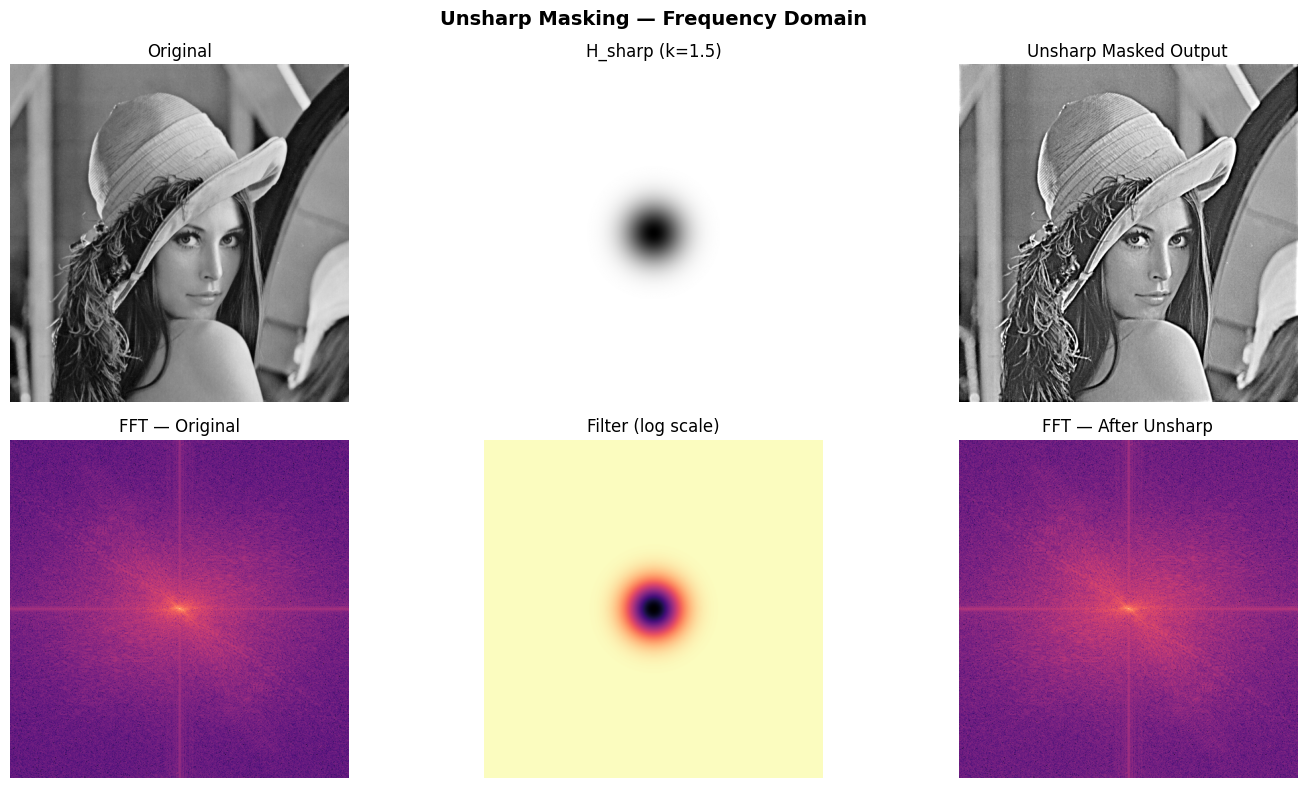

Unsharp masking done ✓


In [2]:
# ── Unsharp Masking in Frequency Domain ──────────────────────────────────────
# Math:
#   H_sharp(u,v) = 1 + k * H_HP(u,v)
#   where H_HP = 1 − H_LP (Gaussian LP mask)
#   OUTPUT = IFFT( FFT(f) · H_sharp )
#
# k controls sharpening strength.
# Equivalent to: sharpened = original + k * (original − lowpass_version)

k = 1.5          # sharpening factor
sigma_um = 30.0  # Gaussian LP sigma (controls which freqs are boosted)

H_lp_gauss = np.exp(-D**2 / (2 * sigma_um**2))  # Gaussian LP mask
H_hp_gauss = 1.0 - H_lp_gauss                   # complementary HP
H_sharp    = 1.0 + k * H_hp_gauss               # unsharp mask filter

Fshift_sharp = Fshift_orig * H_sharp
img_sharp = np.real(np.fft.ifft2(np.fft.ifftshift(Fshift_sharp)))
img_sharp = np.clip(img_sharp, 0, 255)

mag_sharp = np.log1p(np.abs(Fshift_sharp))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Unsharp Masking — Frequency Domain', fontsize=14, fontweight='bold')

axes[0,0].imshow(img, cmap='gray');       axes[0,0].set_title('Original')
axes[0,1].imshow(H_sharp, cmap='gray');   axes[0,1].set_title(f'H_sharp (k={k})')
axes[0,2].imshow(img_sharp, cmap='gray'); axes[0,2].set_title('Unsharp Masked Output')

axes[1,0].imshow(mag_orig, cmap='magma');  axes[1,0].set_title('FFT — Original')
axes[1,1].imshow(np.log1p(H_sharp), cmap='magma'); axes[1,1].set_title('Filter (log scale)')
axes[1,2].imshow(mag_sharp, cmap='magma'); axes[1,2].set_title('FFT — After Unsharp')

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.savefig('unsharp_result.png', dpi=120)
plt.show()
print("Unsharp masking done ✓")

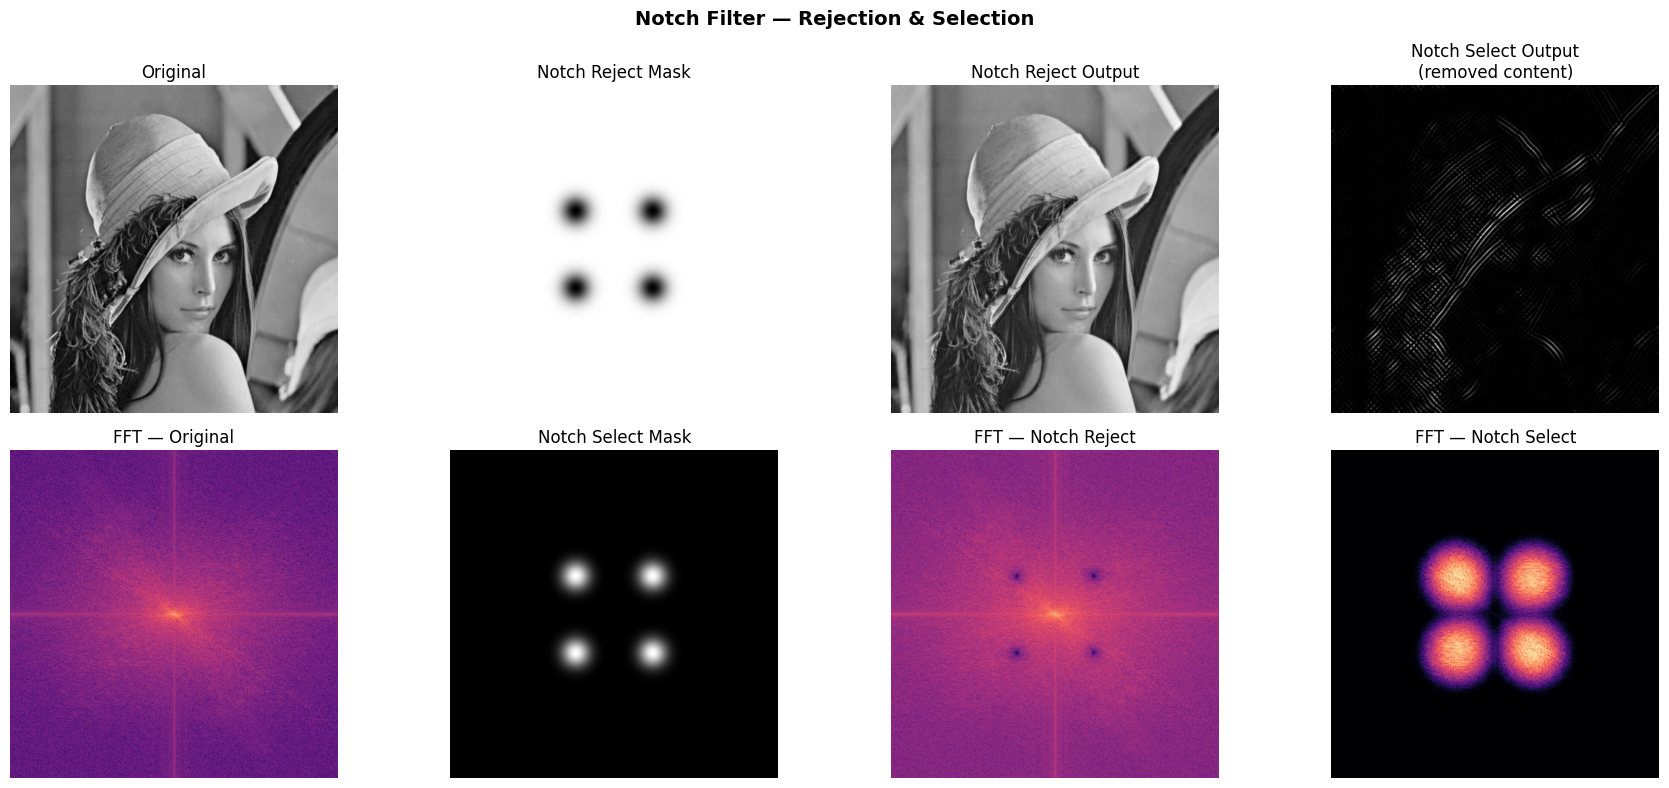

Notch filter done ✓


In [3]:
# ── Notch Filter ──────────────────────────────────────────────────────────────
# Notch Reject: suppress specific frequency pair (u0,v0) and its mirror.
# H_NR = 1 − N1 * N2   where N_k = Gaussian centred at notch centre
# Notch Select (Band-pass notch): H_NS = 1 − H_NR = N1 * N2
# Useful for removing periodic noise (e.g. sinusoidal interference).
#
# We place notches at (±u0, ±v0) which correspond to a chosen interference freq.

cy, cx = rows // 2, cols // 2

# ── Place notch centres at ±(u0, v0) — change to match your image's noise ──
u0, v0 = 60, 60   # offset from centre (pixels in freq domain)
d_notch = 15.0    # notch radius (Gaussian σ)

def gaussian_notch(shape, centres, sigma):
    """
    centres: list of (row_offset, col_offset) from image centre
    Returns product of Gaussian notch masks (values near 0 at each centre).
    """
    r, c = shape
    cy2, cx2 = r // 2, c // 2
    H = np.ones((r, c), dtype=np.float32)
    for (dy, dx) in centres:
        Y, X = np.ogrid[:r, :c]
        dist2 = (X - (cx2 + dx))**2 + (Y - (cy2 + dy))**2
        H *= 1.0 - np.exp(-dist2 / (2 * sigma**2))
    return H

# Symmetric notch pairs
notch_centres = [(v0, u0), (-v0, -u0), (v0, -u0), (-v0, u0)]
H_notch_reject = gaussian_notch(img.shape, notch_centres, d_notch)
H_notch_select = 1.0 - H_notch_reject   # selects the notch frequencies

# Apply notch reject
Fshift_nr = Fshift_orig * H_notch_reject
img_nr = np.real(np.fft.ifft2(np.fft.ifftshift(Fshift_nr)))
img_nr = np.clip(img_nr, 0, 255)

# Apply notch select (shows what was removed)
Fshift_ns = Fshift_orig * H_notch_select
img_ns = np.real(np.fft.ifft2(np.fft.ifftshift(Fshift_ns)))
img_ns = np.clip(img_ns, 0, 255)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Notch Filter — Rejection & Selection', fontsize=14, fontweight='bold')

axes[0,0].imshow(img, cmap='gray');         axes[0,0].set_title('Original')
axes[0,1].imshow(H_notch_reject, cmap='gray'); axes[0,1].set_title('Notch Reject Mask')
axes[0,2].imshow(img_nr, cmap='gray');      axes[0,2].set_title('Notch Reject Output')
axes[0,3].imshow(img_ns, cmap='gray');      axes[0,3].set_title('Notch Select Output\n(removed content)')

axes[1,0].imshow(mag_orig, cmap='magma');   axes[1,0].set_title('FFT — Original')
axes[1,1].imshow(H_notch_select, cmap='gray'); axes[1,1].set_title('Notch Select Mask')
axes[1,2].imshow(np.log1p(np.abs(Fshift_nr)), cmap='magma'); axes[1,2].set_title('FFT — Notch Reject')
axes[1,3].imshow(np.log1p(np.abs(Fshift_ns)), cmap='magma'); axes[1,3].set_title('FFT — Notch Select')

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.savefig('notch_result.png', dpi=120)
plt.show()
print("Notch filter done ✓")

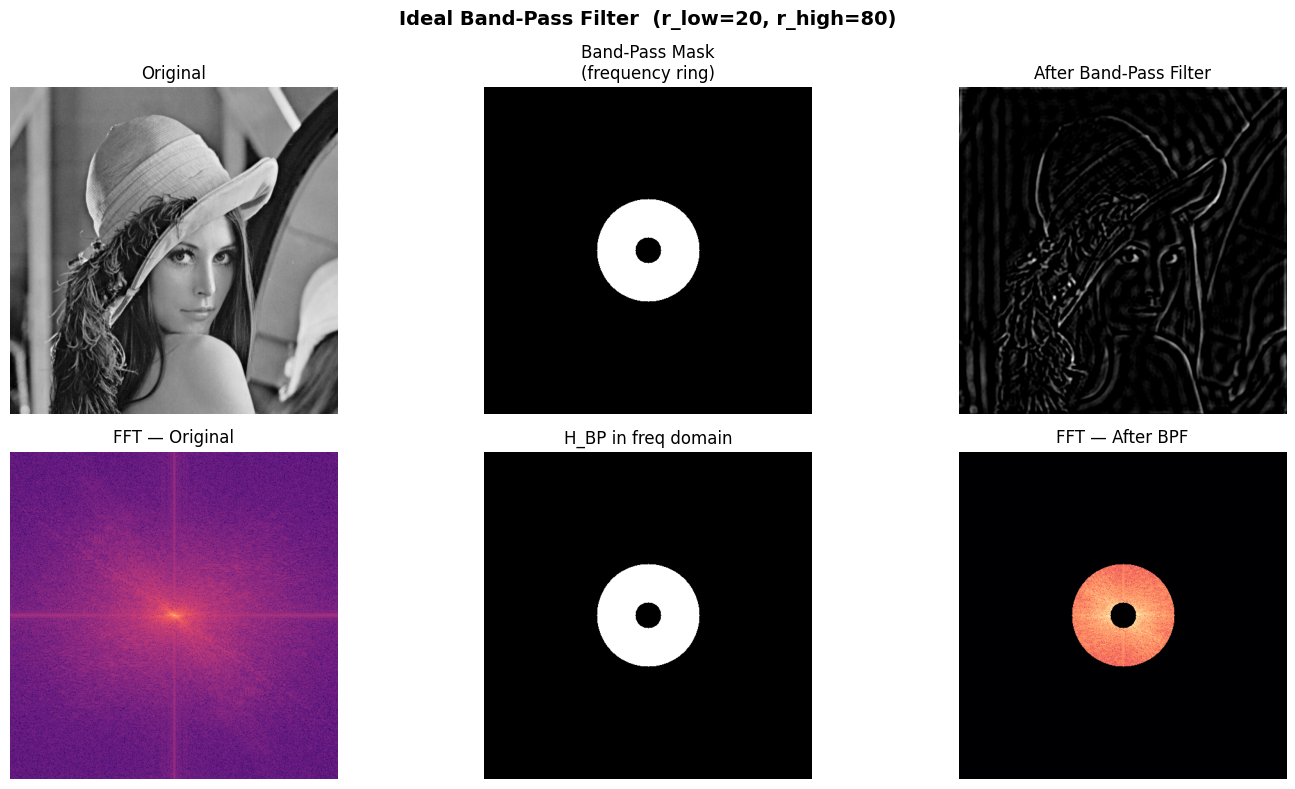

Band-pass filter done ✓


In [4]:
# ── Ideal Band-Pass Filter ────────────────────────────────────────────────────
# Math:
#   H_BP(u,v) = 1   if  r_low ≤ D(u,v) ≤ r_high
#               0   otherwise
# H_BP = H_LP(r_high) − H_LP(r_low)
# Passes a ring of frequencies; blocks DC and very high freqs.

r_low  = 20    # inner radius (blocks low freq / DC)
r_high = 80    # outer radius (blocks very high freq)

# Ideal masks
H_lp_high = (D <= r_high).astype(np.float32)
H_lp_low  = (D <= r_low ).astype(np.float32)
H_bp = H_lp_high - H_lp_low   # annular (ring) mask

Fshift_bp = Fshift_orig * H_bp
img_bp = np.real(np.fft.ifft2(np.fft.ifftshift(Fshift_bp)))
img_bp = np.clip(img_bp, 0, 255)

mag_bp = np.log1p(np.abs(Fshift_bp))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Ideal Band-Pass Filter  (r_low={r_low}, r_high={r_high})', fontsize=14, fontweight='bold')

axes[0,0].imshow(img, cmap='gray');    axes[0,0].set_title('Original')
axes[0,1].imshow(H_bp, cmap='gray');  axes[0,1].set_title('Band-Pass Mask\n(frequency ring)')
axes[0,2].imshow(img_bp, cmap='gray'); axes[0,2].set_title('After Band-Pass Filter')

axes[1,0].imshow(mag_orig, cmap='magma'); axes[1,0].set_title('FFT — Original')
axes[1,1].imshow(H_bp, cmap='gray');      axes[1,1].set_title('H_BP in freq domain')
axes[1,2].imshow(mag_bp, cmap='magma');   axes[1,2].set_title('FFT — After BPF')

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.savefig('bandpass_result.png', dpi=120)
plt.show()
print("Band-pass filter done ✓")

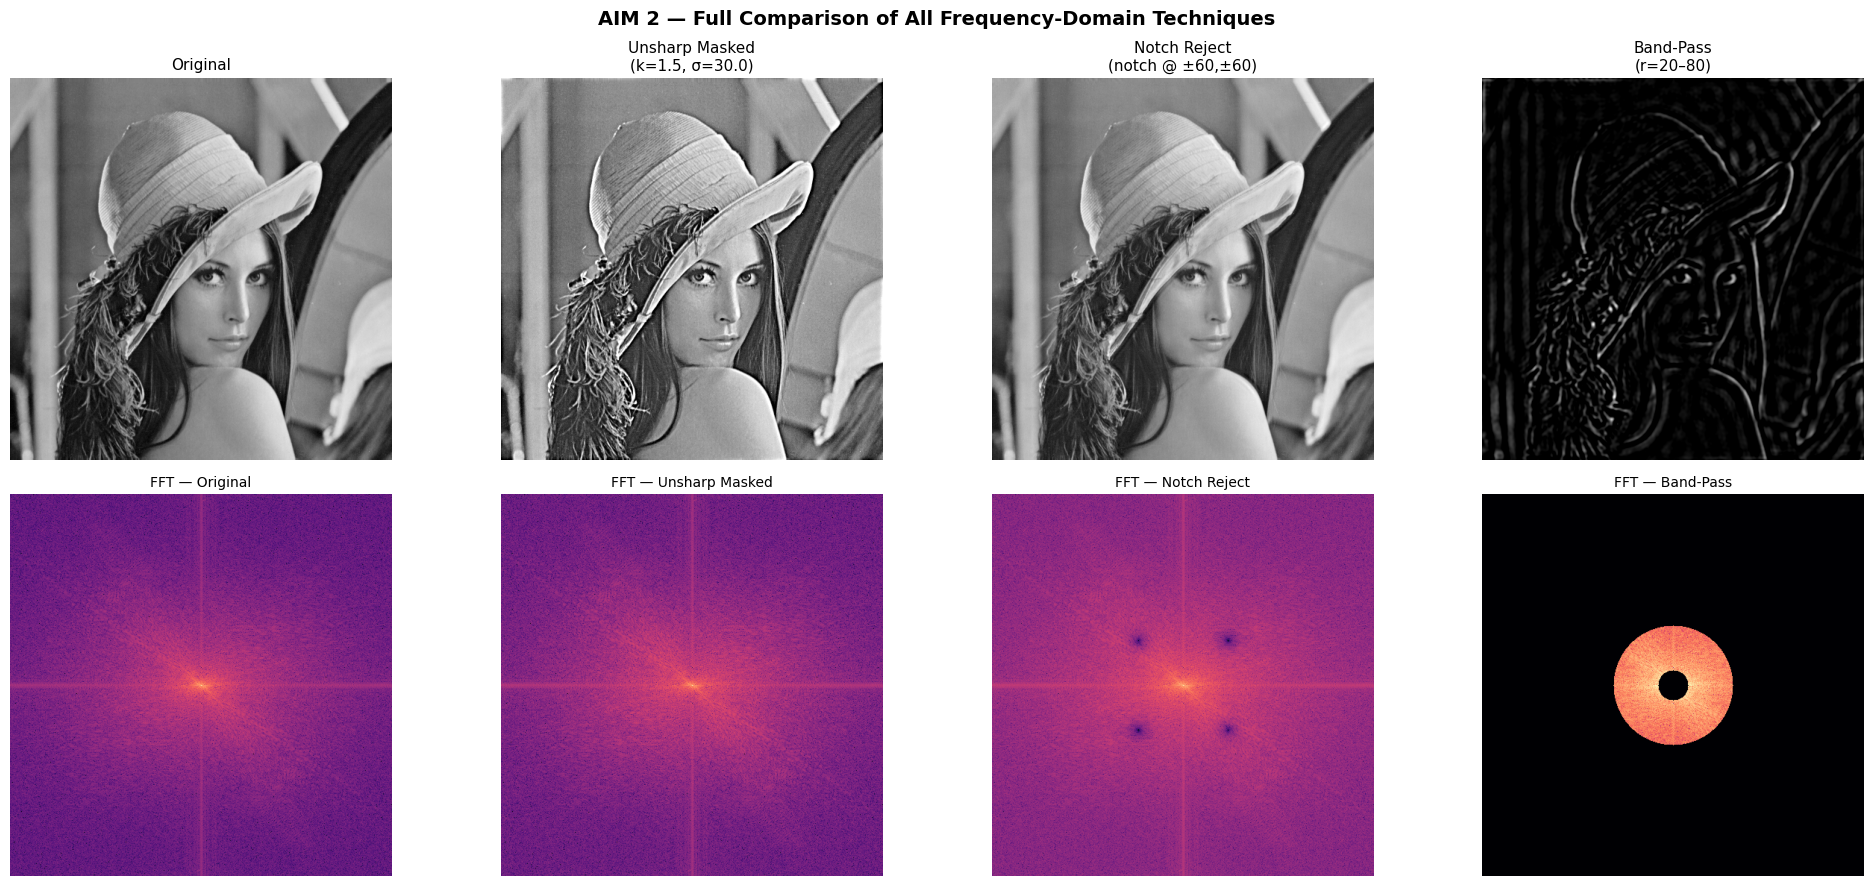

PSNR Unsharp  vs Original : 24.18 dB
PSNR Notch-R  vs Original : 40.49 dB
PSNR Band-Pass vs Original: 5.55 dB
AIM 2 complete ✓


In [5]:
# ── AIM 2 — Final Comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('AIM 2 — Full Comparison of All Frequency-Domain Techniques', fontsize=14, fontweight='bold')

imgs   = [img, img_sharp, img_nr, img_bp]
ffts   = [mag_orig,
          np.log1p(np.abs(Fshift_sharp)),
          np.log1p(np.abs(Fshift_nr)),
          mag_bp]
labels = ['Original',
          f'Unsharp Masked\n(k={k}, σ={sigma_um})',
          f'Notch Reject\n(notch @ ±{u0},±{v0})',
          f'Band-Pass\n(r={r_low}–{r_high})']

for i in range(4):
    axes[0, i].imshow(imgs[i], cmap='gray')
    axes[0, i].set_title(labels[i], fontsize=11)
    axes[1, i].imshow(ffts[i], cmap='magma')
    axes[1, i].set_title(f'FFT — {labels[i].split(chr(10))[0]}', fontsize=10)

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.savefig('aim2_comparison.png', dpi=120)
plt.show()

# Summary stats
def psnr(a, b):
    mse = np.mean((a - b)**2)
    return 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

print(f"PSNR Unsharp  vs Original : {psnr(img, img_sharp):.2f} dB")
print(f"PSNR Notch-R  vs Original : {psnr(img, img_nr):.2f} dB")
print(f"PSNR Band-Pass vs Original: {psnr(img, img_bp):.2f} dB")
print("AIM 2 complete ✓")